[*] Training on device: cuda

Training Transformer Pointer Network for MSA
[MSA] Epoch [00/19] -> LR: 2.00e-04 | Train Loss: 0.2989 | Val Loss: 0.0181 | EM: 94.1% | BLEU: 94.4 | Tau: 99.0 | WER: 0.8%
[MSA] Epoch [01/19] -> LR: 2.00e-04 | Train Loss: 0.0204 | Val Loss: 0.0086 | EM: 95.1% | BLEU: 94.7 | Tau: 99.1 | WER: 0.7%
[MSA] Epoch [02/19] -> LR: 2.00e-04 | Train Loss: 0.0192 | Val Loss: 0.0085 | EM: 95.0% | BLEU: 94.6 | Tau: 99.1 | WER: 0.7%
[MSA] Epoch [03/19] -> LR: 2.00e-04 | Train Loss: 0.0160 | Val Loss: 0.0069 | EM: 97.1% | BLEU: 95.5 | Tau: 99.6 | WER: 0.4%
[MSA] Epoch [04/19] -> LR: 2.00e-04 | Train Loss: 0.0068 | Val Loss: 0.0054 | EM: 98.0% | BLEU: 95.9 | Tau: 99.8 | WER: 0.4%
[MSA] Epoch [05/19] -> LR: 2.00e-04 | Train Loss: 0.0091 | Val Loss: 0.0013 | EM: 98.6% | BLEU: 96.1 | Tau: 99.8 | WER: 0.2%
[MSA] Epoch [06/19] -> LR: 2.00e-04 | Train Loss: 0.0149 | Val Loss: 0.0029 | EM: 98.8% | BLEU: 96.1 | Tau: 99.8 | WER: 0.2%
[MSA] Epoch [07/19] -> LR: 2.00e-04 | Train Loss: 

/tmp/ipykernel_3493/2323332600.py:328: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  tau, _ = stats.kendalltau(true_seq, pred_seq)



------------------------------------ Variant: JO ------------------------------------
| Metric             | Mean Score   | 95% CI (+/-)    | CI Range                     |
-------------------------------------------------------------------------------------
| Exact Match (%)    | 98.62        | 0.81            | [ 97.82,  99.43]             |
| BLEU Score         | 96.62        | 0.93            | [ 95.69,  97.55]             |
| Kendall Tau (%)    | 99.46        | 0.40            | [ 99.06,  99.86]             |
| WER (%)            | 0.20         | 0.12            | [  0.08,   0.32]             |
-------------------------------------------------------------------------------------

Plotting Comparisons...


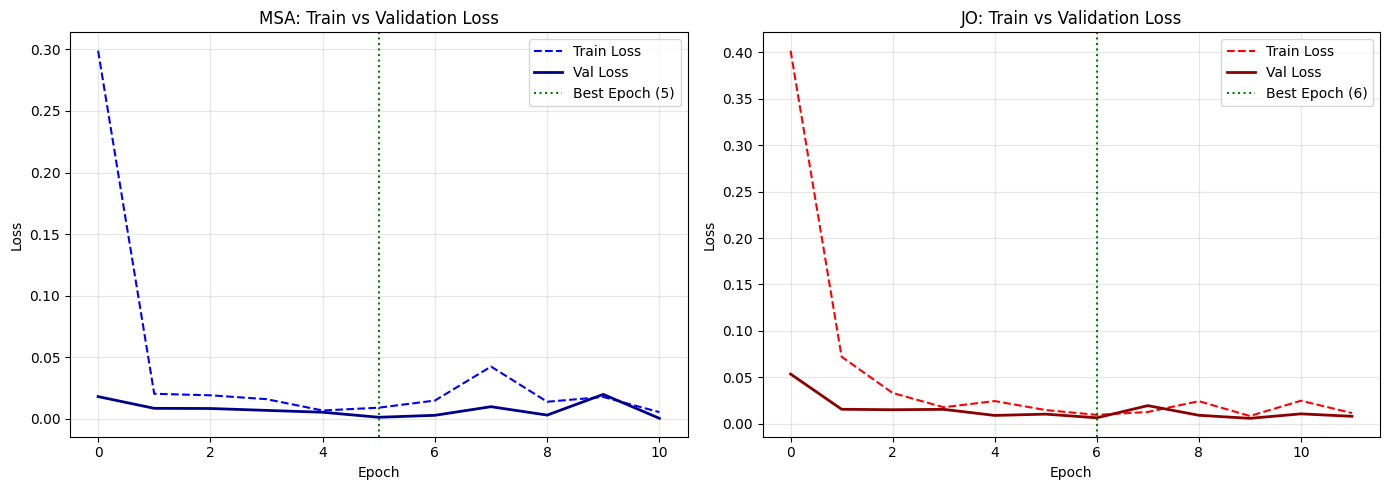

In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from scipy import stats
import sys

current_dir = os.path.abspath(os.getcwd())
root_dir = current_dir
while root_dir and not os.path.exists(os.path.join(root_dir, 'backend')):
    parent = os.path.dirname(root_dir)
    if parent == root_dir: break
    root_dir = parent

backend_dir = os.path.join(root_dir, 'backend')
if os.path.exists(backend_dir) and backend_dir not in sys.path:
    sys.path.append(backend_dir)

try:
    from app.core.nlp_utils import transform_to_arsl
except ImportError:
    def transform_to_arsl(text): return text.split()

def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True 
        torch.backends.cudnn.benchmark = False

set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Training on device: {DEVICE}")

EMBED_MODEL = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2').to(DEVICE)
HIDDEN_DIM = 512 
LR = 2e-4        
BATCH_SIZE = 32  
MAX_LEN = 20
NUM_EPOCHS = 20
WEIGHT_DECAY = 1e-4  
DROPOUT_RATE = 0.2   
PATIENCE = 5     

DATA_DIR = os.path.join(root_dir, 'data', 'new_5k_data')
PATH_MSA_WEIGHTS = os.path.join(DATA_DIR, 'transformer_ptr_msa.pth')
PATH_JO_WEIGHTS = os.path.join(DATA_DIR, 'transformer_ptr_jo.pth')

Q_MARKS = ['?', '؟']
Q_WORDS = ['كيف', 'متى', 'أين', 'لماذا', 'من', 'ماذا', 'هل', 'كم', 'شلون', 'وين', 'ليش', 'مين', 'شو', 'ايمتى', 'قديش'] 
STRUCTURAL_PENALTY_WEIGHT = 5.0

def compute_wer(ref, pred): # Word Error Rate based on Levenshtein distance
    r, p = len(ref), len(pred)
    if r == 0: return 0.0
    d = np.zeros((r + 1, p + 1))
    for i in range(r + 1): d[i, 0] = i
    for j in range(p + 1): d[0, j] = j
    for i in range(1, r + 1):
        for j in range(1, p + 1):
            if ref[i - 1] == pred[j - 1]: d[i, j] = d[i - 1, j - 1]
            else: d[i, j] = 1 + min(d[i - 1, j], d[i, j - 1], d[i - 1, j - 1])
    return d[r, p] / r

class PointerDataset(Dataset):
    def __init__(self, src_lines, tgt_lines):
        self.src_lines = src_lines
        self.tgt_lines = tgt_lines

    def __len__(self): return len(self.src_lines)

    def __getitem__(self, idx):
        source_words = self.src_lines[idx].split()[:MAX_LEN]
        target_words = self.tgt_lines[idx].split()[:MAX_LEN]

        target_indices = []
        for word in target_words:
            if word in source_words: target_indices.append(source_words.index(word))
            else: target_indices.append(0)

        embeddings = EMBED_MODEL.encode(source_words)
        padded_embeds = np.zeros((MAX_LEN, 386))
        weight_mask = np.ones(MAX_LEN)

        for i, word in enumerate(source_words):
            is_q_mark = 1.0 if word in Q_MARKS else 0.0
            is_q_word = 1.0 if word in Q_WORDS else 0.0
            padded_embeds[i] = np.concatenate([embeddings[i], [is_q_mark, is_q_word]])

        for i, t_idx in enumerate(target_indices):
            if t_idx < len(source_words):
                tgt_word = source_words[t_idx]
                if tgt_word in Q_MARKS or tgt_word in Q_WORDS:
                    weight_mask[i] = STRUCTURAL_PENALTY_WEIGHT

        padded_targets = np.full(MAX_LEN, -1)
        padded_targets[:len(target_indices)] = target_indices
        return torch.FloatTensor(padded_embeds), torch.LongTensor(padded_targets), len(source_words), torch.FloatTensor(weight_mask)

class TransformerPointerNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, max_len=MAX_LEN, nhead=4, num_layers=3, dropout_rate=DROPOUT_RATE):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.max_len = max_len
        self.input_projection = nn.Linear(input_dim, hidden_dim)
        self.pos_embedding = nn.Embedding(max_len, hidden_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=nhead, dim_feedforward=hidden_dim*2, dropout=dropout_rate, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        decoder_layer = nn.TransformerDecoderLayer(d_model=hidden_dim, nhead=nhead, dim_feedforward=hidden_dim*2, dropout=dropout_rate, batch_first=True)
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.vt = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout_rate)
        self.start_token = nn.Parameter(torch.zeros(1, 1, hidden_dim))

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        x_proj = self.input_projection(x)
        positions = torch.arange(0, seq_len, device=x.device).unsqueeze(0).repeat(batch_size, 1)
        enc_input = x_proj + self.pos_embedding(positions)
        enc_input = self.dropout(enc_input)
        memory = self.encoder(enc_input)
        all_logits = []
        dec_input = self.start_token.expand(batch_size, -1, -1)
        
        for step in range(seq_len):
            dec_out = self.decoder(dec_input, memory)
            query = dec_out[:, -1, :] 
            out = torch.tanh(self.W1(memory) + self.W2(query).unsqueeze(1))
            logits = self.vt(out).squeeze(2)
            all_logits.append(logits)
            if step < seq_len - 1:
                next_token = query.unsqueeze(1)
                dec_input = torch.cat([dec_input, next_token], dim=1)
                
        return torch.stack(all_logits, dim=1)

def evaluate_metrics(model, dataloader):
    model.eval()
    em_correct, total = 0, 0
    bleu_scores, tau_scores, wer_scores = [], [], []
    smooth = SmoothingFunction().method1

    with torch.no_grad():
        for x, y, _, _ in dataloader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            output = model(x)
            preds = output.argmax(dim=-1)

            for i in range(len(y)):
                valid_len = (y[i] != -1).sum().item()
                if valid_len == 0: continue
                
                pred_seq = preds[i][:valid_len].tolist()
                true_seq = y[i][:valid_len].tolist()
                
                pred_str_seq = [str(idx) for idx in pred_seq]
                true_str_seq = [str(idx) for idx in true_seq]

                if pred_seq == true_seq: em_correct += 1
                bleu_scores.append(sentence_bleu([true_str_seq], pred_str_seq, smoothing_function=smooth))
                wer_scores.append(compute_wer(true_seq, pred_seq))
                
                tau, _ = stats.kendalltau(true_seq, pred_seq)
                if not np.isnan(tau): tau_scores.append(max(0, tau)) 
                total += 1
                
    em_score = (em_correct / total) * 100 if total > 0 else 0
    bleu_avg = np.mean(bleu_scores) * 100 if bleu_scores else 0
    tau_avg = np.mean(tau_scores) * 100 if tau_scores else 0
    wer_avg = np.mean(wer_scores) * 100 if wer_scores else 0
    
    return bleu_avg, em_score, tau_avg, wer_avg

def train_and_validate(train_loader, val_loader, variant_name, patience=PATIENCE):
    model = TransformerPointerNet(386, HIDDEN_DIM).to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    criterion = nn.CrossEntropyLoss(ignore_index=-1, reduction='none')
    
    history = {'train_loss': [], 'val_loss': [], 'val_bleu': [], 'val_em': [], 'val_tau': [], 'val_wer': [], 'best_epoch': 0}
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_weights = None
    
    # require the loss to drop by at least this much to count as an improvement
    min_delta = 1e-3

    for epoch in range(NUM_EPOCHS):
        model.train()
        train_loss = 0
        for x, y, _, weight_mask in train_loader:
            x, y, weight_mask = x.to(DEVICE), y.to(DEVICE), weight_mask.to(DEVICE)
            optimizer.zero_grad()
            output = model(x)
            raw_loss = criterion(output.view(-1, MAX_LEN), y.view(-1))
            loss = (raw_loss * weight_mask.view(-1)).mean()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()
            
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y, _, weight_mask in val_loader:
                x, y, weight_mask = x.to(DEVICE), y.to(DEVICE), weight_mask.to(DEVICE)
                output = model(x)
                raw_loss = criterion(output.view(-1, MAX_LEN), y.view(-1))
                val_loss += (raw_loss * weight_mask.view(-1)).mean().item()

        avg_train = train_loss / len(train_loader)
        avg_val = val_loss / len(val_loader)
        val_bleu, val_em, val_tau, val_wer = evaluate_metrics(model, val_loader)
        
        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        history['val_bleu'].append(val_bleu)
        history['val_em'].append(val_em)
        history['val_tau'].append(val_tau)
        history['val_wer'].append(val_wer)

        scheduler.step(avg_val)
        
        current_lr = optimizer.param_groups[0]['lr'] # for logging

        if avg_val < (best_val_loss - min_delta):
            best_val_loss = avg_val
            patience_counter = 0
            best_model_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            history['best_epoch'] = epoch
        else:
            patience_counter += 1

        print(f"[{variant_name}] Epoch [{epoch:02d}/{NUM_EPOCHS-1}] -> "
              f"LR: {current_lr:.2e} | "
              f"Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f} | "
              f"EM: {val_em:.1f}% | BLEU: {val_bleu:.1f} | Tau: {val_tau:.1f} | WER: {val_wer:.1f}%")
              
        if patience_counter >= patience: 
            print(f"[{variant_name}] Early stopping triggered after no significant validation improvement for {patience} epochs.")
            break
     
    if best_model_weights is not None: 
        model.load_state_dict(best_model_weights)
    return model, history

def load_aligned_data(src_path, tgt_path):
    if not os.path.exists(src_path) or not os.path.exists(tgt_path): return [], []
    with open(src_path, 'r', encoding='utf-8') as f: src_lines = [l.strip() for l in f if l.strip()]
    with open(tgt_path, 'r', encoding='utf-8') as f: tgt_lines = [l.strip().replace("Output:", "").strip() for l in f if l.strip()]
    return src_lines, tgt_lines

# Plotting 
def plot_training_histories(histories):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    
    for i, name in enumerate(['MSA', 'JO']):
        if name in histories:
            h = histories[name]
            axs[i].plot(h['train_loss'], label='Train Loss', linestyle='--', color='blue' if name=='MSA' else 'red')
            axs[i].plot(h['val_loss'], label='Val Loss', linewidth=2, color='darkblue' if name=='MSA' else 'darkred')
            
            # the vertical line
            best_ep = h['best_epoch']
            axs[i].axvline(x=best_ep, color='green', linestyle=':', label=f'Best Epoch ({best_ep})')
            
            axs[i].set_title(f'{name}: Train vs Validation Loss')
            axs[i].set_xlabel('Epoch')
            axs[i].set_ylabel('Loss')
            axs[i].legend()
            axs[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('transformer_training_metrics_comprehensive.png')
    plt.show()

def evaluate_test_metrics_with_ci(model, dataloader):
    model.eval()
    em_scores, bleu_scores, tau_scores, wer_scores = [], [], [], []
    smooth = SmoothingFunction().method1

    with torch.no_grad():
        for x, y, _, _ in dataloader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            output = model(x)
            preds = output.argmax(dim=-1)

            for i in range(len(y)):
                valid_len = (y[i] != -1).sum().item()
                if valid_len == 0: continue
                
                pred_seq = preds[i][:valid_len].tolist()
                true_seq = y[i][:valid_len].tolist()
                
                pred_str_seq = [str(idx) for idx in pred_seq]
                true_str_seq = [str(idx) for idx in true_seq]

                # store individual scores (scaled to 100 for percentage representations)
                em_scores.append(100.0 if pred_seq == true_seq else 0.0)
                bleu_scores.append(sentence_bleu([true_str_seq], pred_str_seq, smoothing_function=smooth) * 100)
                wer_scores.append(compute_wer(true_seq, pred_seq) * 100)
                
                tau, _ = stats.kendalltau(true_seq, pred_seq)
                tau_scores.append(max(0, tau) * 100 if not np.isnan(tau) else 0.0)
                
    def get_95_ci(data):
        n = len(data)
        if n < 2: return np.mean(data), 0.0
        mean = np.mean(data)
        se = stats.sem(data)
        # calculate Margin of Error (95% CI)
        margin = se * stats.t.ppf((1 + 0.95) / 2., n-1) 
        return mean, margin
        
    return {
        'Exact Match (%)': get_95_ci(em_scores),
        'BLEU Score': get_95_ci(bleu_scores),
        'Kendall Tau (%)': get_95_ci(tau_scores),
        'WER (%)': get_95_ci(wer_scores)
    }

if __name__ == "__main__":
    variants = {
        'MSA': {'src': os.path.join(DATA_DIR, 'msa_og_nlp_processed.txt'), 'tgt': os.path.join(DATA_DIR, 'msa_targets.txt'), 'weights': PATH_MSA_WEIGHTS},
        'JO': {'src': os.path.join(DATA_DIR, 'jo_og_nlp_processed.txt'), 'tgt': os.path.join(DATA_DIR, 'jo_targets.txt'), 'weights': PATH_JO_WEIGHTS}
    }
    
    all_histories = {}
    test_loaders = {}
    final_models = {}
    
    for name, paths in variants.items():
        print(f"\nTraining Transformer Pointer Network for {name}")
        src_lines, tgt_lines = load_aligned_data(paths['src'], paths['tgt'])
        if not src_lines: 
            print(f"Data not found for {name}, skipping.")
            continue
            
        # to shuffle in unison
        combined = list(zip(src_lines, tgt_lines))
        random.shuffle(combined)
        src_lines, tgt_lines = zip(*combined)
        src_lines, tgt_lines = list(src_lines), list(tgt_lines)
        
        # 80% Train 10% Val 10% Test
        total_len = len(src_lines)
        train_end = int(total_len * 0.8)
        val_end = int(total_len * 0.9)
        
        train_ds = PointerDataset(src_lines[:train_end], tgt_lines[:train_end])
        val_ds = PointerDataset(src_lines[train_end:val_end], tgt_lines[train_end:val_end])
        test_ds = PointerDataset(src_lines[val_end:], tgt_lines[val_end:])
        
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
        test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
        
        model, history = train_and_validate(train_loader, val_loader, name)
        torch.save({'model_state': model.state_dict()}, paths['weights'])
        print(f"Successfully saved Transformer weights to {paths['weights']}")
        
        all_histories[name] = history
        test_loaders[name] = test_loader
        final_models[name] = model
        
    print("\n" + "="*85)
    print(f"{'TEST SET EVALUATION SUMMARY (WITH 95% CIs)':^85}")
    print("="*85)
    
    for name in final_models:
        # Get dictionary of {Metric: (Mean, Margin_of_Error)}
        results = evaluate_test_metrics_with_ci(final_models[name], test_loaders[name])
        
        print(f"\n{f' Variant: {name} ':-^85}")
        print(f"| {'Metric':<18} | {'Mean Score':<12} | {'95% CI (+/-)':<15} | {'CI Range':<28} |")
        print("-" * 85)
        
        for metric_name, (mean, margin) in results.items():
            lower_bound = max(0.0, mean - margin) 
            upper_bound = min(100.0, mean + margin) # cap percentages at 100
            ci_range = f"[{lower_bound:>6.2f}, {upper_bound:>6.2f}]"
            
            print(f"| {metric_name:<18} | {mean:<12.2f} | {margin:<15.2f} | {ci_range:<28} |")
            
        print("-" * 85)

    if all_histories:
        print("\nPlotting Comparisons...")
        plot_training_histories(all_histories)

## inference

In [ ]:
import os
import sys
import torch
import numpy as np
from sentence_transformers import SentenceTransformer

current_dir = os.path.abspath(os.getcwd())
root_dir = current_dir
while root_dir and not os.path.exists(os.path.join(root_dir, 'backend')):
    parent = os.path.dirname(root_dir)
    if parent == root_dir: break
    root_dir = parent

backend_dir = os.path.join(root_dir, 'backend')
if os.path.exists(backend_dir) and backend_dir not in sys.path:
    sys.path.append(backend_dir)

try:
    from app.core.nlp_utils import transform_to_arsl
except ImportError:
    def transform_to_arsl(text): return text.split()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

EMBED_MODEL = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2').to(DEVICE)
HIDDEN_DIM = 512
MAX_LEN = 20

Q_MARKS = ['?', '؟']
Q_WORDS = ['كيف', 'متى', 'أين', 'لماذا', 'من', 'ماذا', 'هل', 'كم', 'شلون', 'وين', 'ليش', 'مين', 'شو', 'ايمتى', 'قديش'] 

DATA_DIR = os.path.join(root_dir, 'data', 'new_5k_data')
PATH_MSA_WEIGHTS = os.path.join(DATA_DIR, 'transformer_ptr_msa.pth')
PATH_JO_WEIGHTS = os.path.join(DATA_DIR, 'transformer_ptr_jo.pth')

import torch.nn as nn
class TransformerPointerNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, max_len=MAX_LEN, nhead=4, num_layers=3, dropout_rate=0.2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.max_len = max_len
        self.input_projection = nn.Linear(input_dim, hidden_dim)
        self.pos_embedding = nn.Embedding(max_len, hidden_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=nhead, dim_feedforward=hidden_dim*2, dropout=dropout_rate, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        decoder_layer = nn.TransformerDecoderLayer(d_model=hidden_dim, nhead=nhead, dim_feedforward=hidden_dim*2, dropout=dropout_rate, batch_first=True)
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.vt = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout_rate)
        self.start_token = nn.Parameter(torch.zeros(1, 1, hidden_dim))

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        x_proj = self.input_projection(x)
        positions = torch.arange(0, seq_len, device=x.device).unsqueeze(0).repeat(batch_size, 1)
        enc_input = x_proj + self.pos_embedding(positions)
        enc_input = self.dropout(enc_input)
        memory = self.encoder(enc_input)
        all_logits = []
        dec_input = self.start_token.expand(batch_size, -1, -1)
        for step in range(seq_len):
            dec_out = self.decoder(dec_input, memory)
            query = dec_out[:, -1, :] 
            out = torch.tanh(self.W1(memory) + self.W2(query).unsqueeze(1))
            logits = self.vt(out).squeeze(2)
            all_logits.append(logits)
            if step < seq_len - 1:
                next_token = query.unsqueeze(1)
                dec_input = torch.cat([dec_input, next_token], dim=1)
        return torch.stack(all_logits, dim=1)

def load_model(path):
    model = TransformerPointerNet(386, HIDDEN_DIM).to(DEVICE)
    if os.path.exists(path):
        checkpoint = torch.load(path, map_location=DEVICE, weights_only=True)
        model.load_state_dict(checkpoint['model_state'])
        model.eval()
        return model
    else:
        print(f"[Warning] Weights not found at {path}")
        return None

def predict_arsl(model, text):
    if not model: return "Model not loaded."
    
    nlp_tokens = transform_to_arsl(text)
    if not nlp_tokens: return ""
    
    # Enforce MAX_LEN
    nlp_tokens = nlp_tokens[:MAX_LEN]
    n = len(nlp_tokens)
    
    # build 386-dim input embeddings
    embeddings = EMBED_MODEL.encode(nlp_tokens)
    features = np.zeros((n, 2))
    for j, w in enumerate(nlp_tokens):
        if w in Q_MARKS: features[j, 0] = 1.0
        if w in Q_WORDS: features[j, 1] = 1.0
        
    combined_emb = np.concatenate([embeddings, features], axis=1)
    
    padded_x = torch.zeros(1, MAX_LEN, 386).to(DEVICE)
    padded_x[0, :n] = torch.FloatTensor(combined_emb)
    
    with torch.no_grad():
        logits = model(padded_x)[0]  # Shape: (MAX_LEN, MAX_LEN)
        
    # Pointer extraction with masking to prevent repeats
    indices = []
    mask = torch.zeros(n).to(DEVICE)
    
    for step in range(n):
        step_logits = logits[step, :n] + mask
        idx = torch.argmax(step_logits).item()
        indices.append(idx)
        mask[idx] = -1e9  # Mask out the chosen word so it's not picked again
        
    predicted_words = [nlp_tokens[idx] for idx in indices]
    return " ".join(predicted_words)

if __name__ == "__main__":
    print("\nLoading models...")
    msa_model = load_model(PATH_MSA_WEIGHTS)
    jo_model = load_model(PATH_JO_WEIGHTS)
    
    if not msa_model and not jo_model:
        print("Could not load any models.")
        sys.exit()

    print("\n" + "="*50)
    print("ArSL Pointer Network Inference")
    print("Type 'exit' or 'quit' to stop.")
    print("="*50 + "\n")

    while True:
        try:
            raw_input = input("\nEnter an Arabic sentence: ").strip()
            if raw_input.lower() in ['exit', 'quit']: break
            if not raw_input: continue

            print("\nPredictions")
            
            if msa_model:
                msa_pred = predict_arsl(msa_model, raw_input)
                print(f"MSA Model Output : {msa_pred}")
                
            if jo_model:
                jo_pred = predict_arsl(jo_model, raw_input)
                print(f"JO Model Output  : {jo_pred}")
                
            print("-" * 19)

        except KeyboardInterrupt:
            break
            
    print("\nExiting inference loop")

Using device: cuda

Loading models... This might take a few seconds.

ArSL Pointer Network Inference
Type 'exit' or 'quit' to stop.


--- Predictions ---
transform_to_arsl received: 'اين ذهب الولد ؟'
MSA Model Output : ؟ قبل ذهب ولد اين
transform_to_arsl received: 'اين ذهب الولد ؟'
JO Model Output  : ؟ قبل ذهب ولد اين
-------------------

--- Predictions ---
transform_to_arsl received: 'الدكتور عمر القاضي مدرس مادة الجبر الخطي'
MSA Model Output : دكتور عمر قاضي مدرس مادة جبر خطي
transform_to_arsl received: 'الدكتور عمر القاضي مدرس مادة الجبر الخطي'
JO Model Output  : دكتور عمر قاضي مدرس مادة جبر خطي
-------------------

--- Predictions ---
transform_to_arsl received: 'اكل احمد التفاحة'
MSA Model Output : قبل أكل أحمد تفاح
transform_to_arsl received: 'اكل احمد التفاحة'
JO Model Output  : قبل أكل أحمد تفاح
-------------------

--- Predictions ---
transform_to_arsl received: 'امل احمد التفاحة ثم اكل البرتقالة'
MSA Model Output : أمل أحمد تفاح قبل أكل البرتقاله
transform_to_arsl received: 